# Chest X-Ray Pneumonia Detection
### Convolutional Neural Network with Keras

Pneumonia is a life-threatening lung infection that kills over **2 million children under 5 every year**.
Diagnosing it requires a trained radiologist to examine a chest X-ray a resource not always available
in under-resourced hospitals.

**Goal:** Train a Convolutional Neural Network (CNN) to classify chest X-rays as **Normal** or **Pneumonia** automating a task that typically requires medical expertise.

**Dataset:** 5,863 chest X-ray images (JPEG) from Guangzhou Women and Children's Medical Center,
split into train / validation / test sets across two classes: NORMAL and PNEUMONIA.


**Key challenge:** The dataset is imbalanced almst 3× more Pneumonia cases than Normal.
A model that predicts Pneumonia for every patient gets 74% accuracy but is medically useless.
We prioritise **Recall** as catching every sick patient matters more than avoiding false alarms.

Lets go my first CNN project!!!

In [1]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator #loads in segments (not entirely at one)
from sklearn.metrics import classification_report, confusion_matrix
import os

%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Lets load the data
train_dir = '/content/drive/MyDrive/CNN_ChestXray_data/chest_xray/train'
test_dir  = '/content/drive/MyDrive/CNN_ChestXray_data/chest_xray/test'
val_dir   = '/content/drive/MyDrive/CNN_ChestXray_data/chest_xray/val'

print("TRAIN SET:")
print(f"  Normal:    {len(os.listdir(train_dir + '/NORMAL'))}")
print(f"  Pneumonia: {len(os.listdir(train_dir + '/PNEUMONIA'))}")

print("\nTEST SET:")
print(f"  Normal:    {len(os.listdir(test_dir + '/NORMAL'))}")
print(f"  Pneumonia: {len(os.listdir(test_dir + '/PNEUMONIA'))}")

print("\nVAL SET:")
print(f"  Normal:    {len(os.listdir(val_dir + '/NORMAL'))}")
print(f"  Pneumonia: {len(os.listdir(val_dir + '/PNEUMONIA'))}")

TRAIN SET:
  Normal:    1341
  Pneumonia: 3875

TEST SET:
  Normal:    234
  Pneumonia: 390

VAL SET:
  Normal:    8
  Pneumonia: 8


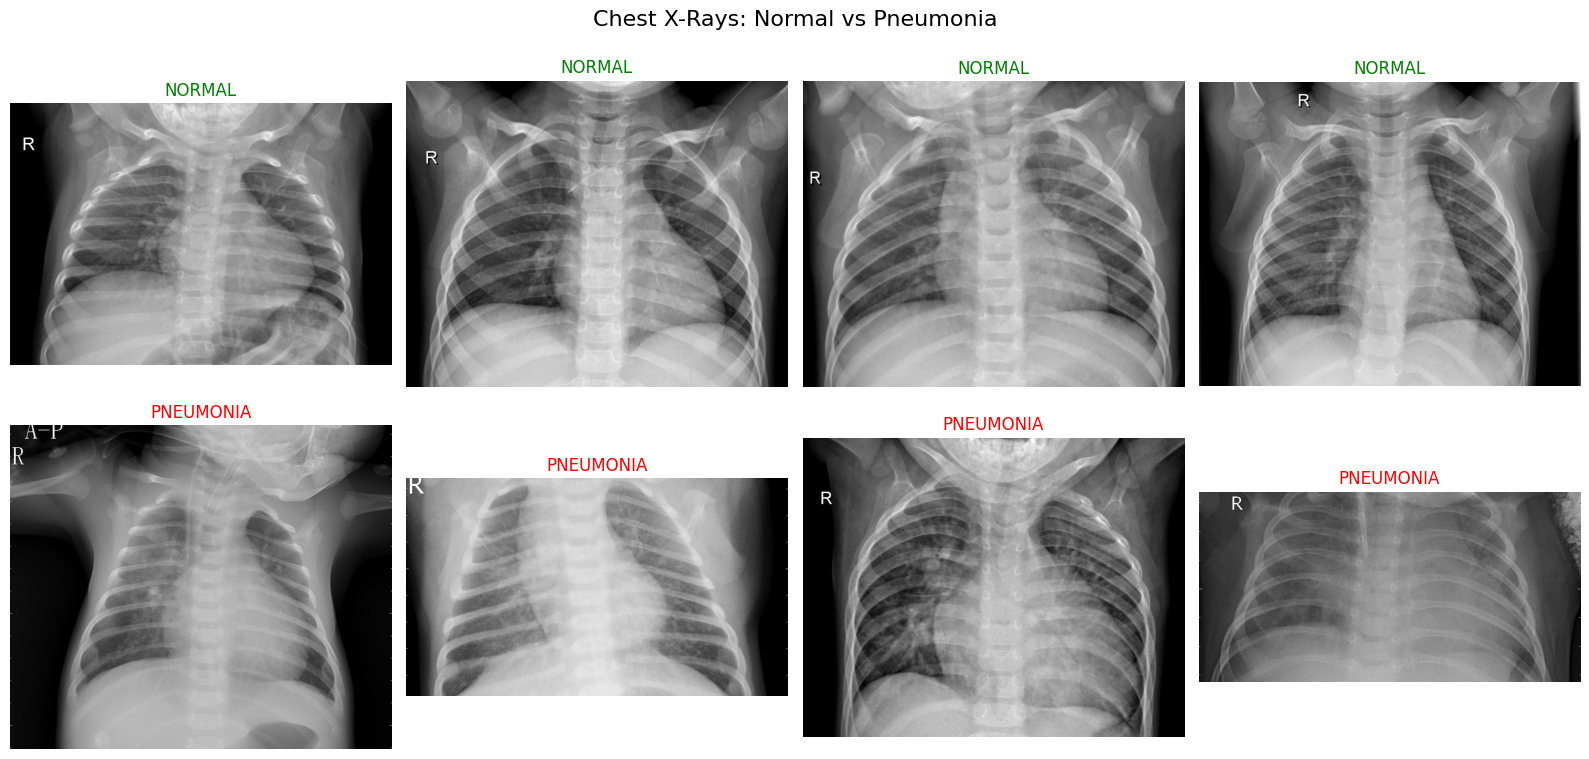

In [4]:
#Now let's visualise some actual X-rays before we build anything.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Normal X-rays
normal_imgs = os.listdir(train_dir + '/NORMAL')[:4]
for i, img_name in enumerate(normal_imgs):
    img = mpimg.imread(train_dir + '/NORMAL/' + img_name)
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title('NORMAL', color='green', fontsize=12)
    axes[0, i].axis('off')

# Pneumonia X-rays
pneumonia_imgs = os.listdir(train_dir + '/PNEUMONIA')[:4]
for i, img_name in enumerate(pneumonia_imgs):
    img = mpimg.imread(train_dir + '/PNEUMONIA/' + img_name)
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title('PNEUMONIA', color='red', fontsize=12)
    axes[1, i].axis('off')

plt.suptitle('Chest X-Rays: Normal vs Pneumonia', fontsize=16)
plt.tight_layout()
plt.show()

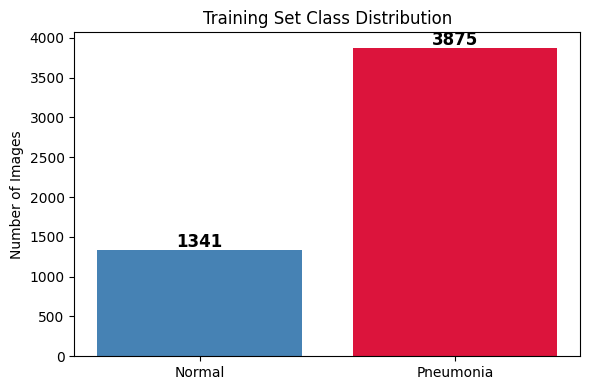

Imbalance ratio: 2.9x more Pneumonia than Normal


In [5]:
#Lets check the lass distrbution
categories = ['Normal', 'Pneumonia']
train_counts = [len(os.listdir(train_dir + '/NORMAL')),
                len(os.listdir(train_dir + '/PNEUMONIA'))]

plt.figure(figsize=(6, 4))
bars = plt.bar(categories, train_counts, color=['steelblue', 'crimson'])
plt.title('Training Set Class Distribution')
plt.ylabel('Number of Images')

#Add count labels on top of each bar
for bar, count in zip(bars, train_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Imbalance ratio: {train_counts[1]/train_counts[0]:.1f}x more Pneumonia than Normal")

In [6]:
#Training generator and we augment the dataset for obvs reason
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

#test generator we ONLY rescale, no augmentation as we need real data to test
test_datagen = ImageDataGenerator(rescale=1./255)

#lets load training images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

#lets load test images
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    color_mode='grayscale'
)

print(f"\nClass indices: {train_generator.class_indices}")

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [7]:
#Now we calculate class weights to handle imbalance
total = len(train_generator.filenames)
normal_count = train_counts[0]
pneumonia_count = train_counts[1]

class_weight = {
    0: total / (2 * normal_count),    # Normal
    1: total / (2 * pneumonia_count)  # Pneumonia
}

print(f"Normal weight:    {class_weight[0]:.4f}")
print(f"Pneumonia weight: {class_weight[1]:.4f}")

Normal weight:    1.9448
Pneumonia weight: 0.6730


In [8]:
#Finally the CNN lets go!
#CNN Architecture: 3 Conv+Pool blocks -> Flatten -> Dense -> Sigmoid output (full e2e)
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,1)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,827,905 (18.42 MB)

 Trainable params: 4,827,905 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#Compiling the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

In [10]:
#Lets train the model
history = model.fit(
    train_generator,
    steps_per_epoch=163,
    epochs=10,
    validation_data=test_generator,
    validation_steps=19,
    class_weight=class_weight
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.8012 - loss: 0.3809 - recall: 0.7825 - val_accuracy: 0.8553 - val_loss: 0.3198 - val_recall: 0.9519
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 400ms/step - accuracy: 0.9091 - loss: 0.2170 - recall: 0.9061 - val_accuracy: 0.8355 - val_loss: 0.4880 - val_recall: 0.9706
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 405ms/step - accuracy: 0.9275 - loss: 0.1865 - recall: 0.9236 - val_accuracy: 0.8931 - val_loss: 0.2978 - val_recall: 0.9225
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 502ms/step - accuracy: 0.9398 - loss: 0.1603 - recall: 0.9370 - val_accuracy: 0.8766 - val_loss: 0.3249 - val_recall: 0.9412
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 401ms/step - accuracy: 0.9410 - loss: 0.1588 - recall: 0.9383 - val_accuracy: 0.8388 - val_loss: 0.4363 - val_recall: 0.9813
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 395ms/step - accuracy: 0.9465 - loss: 0.1410 - recall: 0.9453 - val_accuracy: 0.8734 - val_loss: 0.3754 - val_rec

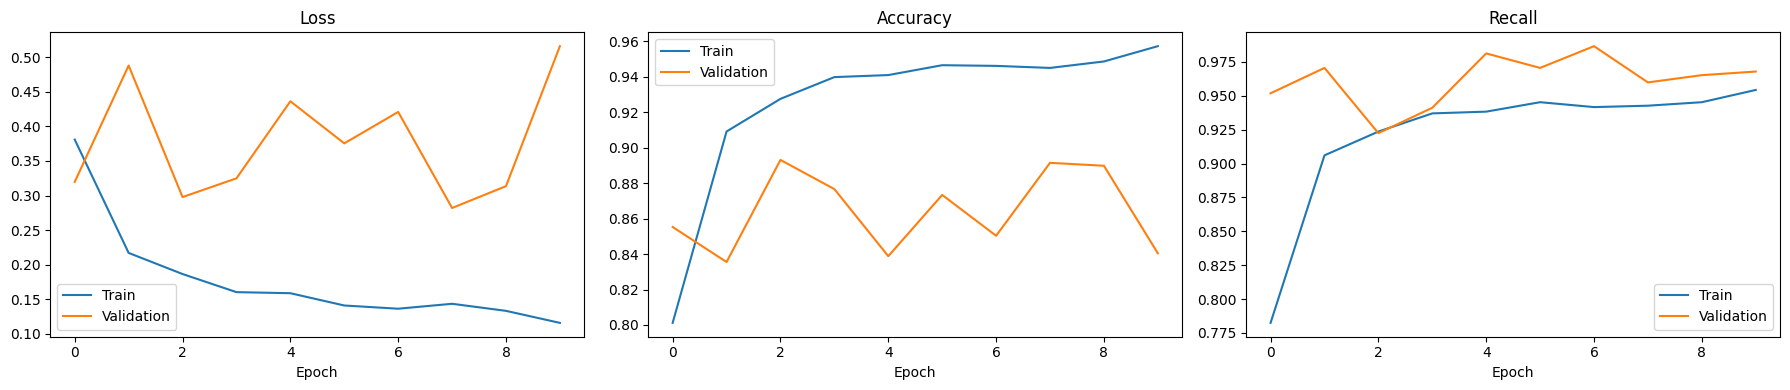

In [11]:
#Lets visualise the learning curve n check
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

#Loss
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

#Accuracy
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

#Recall
axes[2].plot(history.history['recall'], label='Train')
axes[2].plot(history.history['val_recall'], label='Validation')
axes[2].set_title('Recall')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

In [12]:
#Reset test generator before evaluation
test_generator.reset()

#Evaluate
results = model.evaluate(test_generator)
print(f"\nTest Loss:     {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test Recall:   {results[2]:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - accuracy: 0.8446 - loss: 0.5030 - recall: 0.9692

Test Loss:     0.5030
Test Accuracy: 0.8446
Test Recall:   0.9692


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step


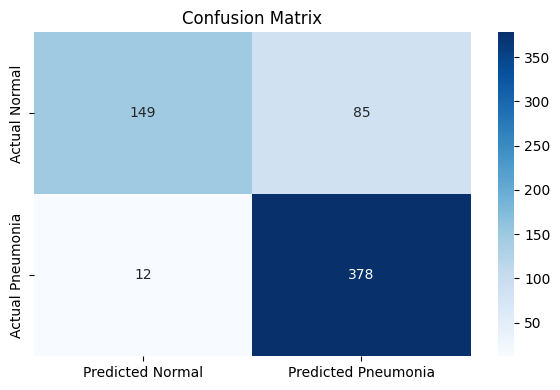

              precision    recall  f1-score   support

      Normal       0.93      0.64      0.75       234
   Pneumonia       0.82      0.97      0.89       390

    accuracy                           0.84       624
   macro avg       0.87      0.80      0.82       624
weighted avg       0.86      0.84      0.84       624



In [13]:
#Lets get predictions
test_generator.reset()
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

#Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Pneumonia'],
            yticklabels=['Actual Normal', 'Actual Pneumonia'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

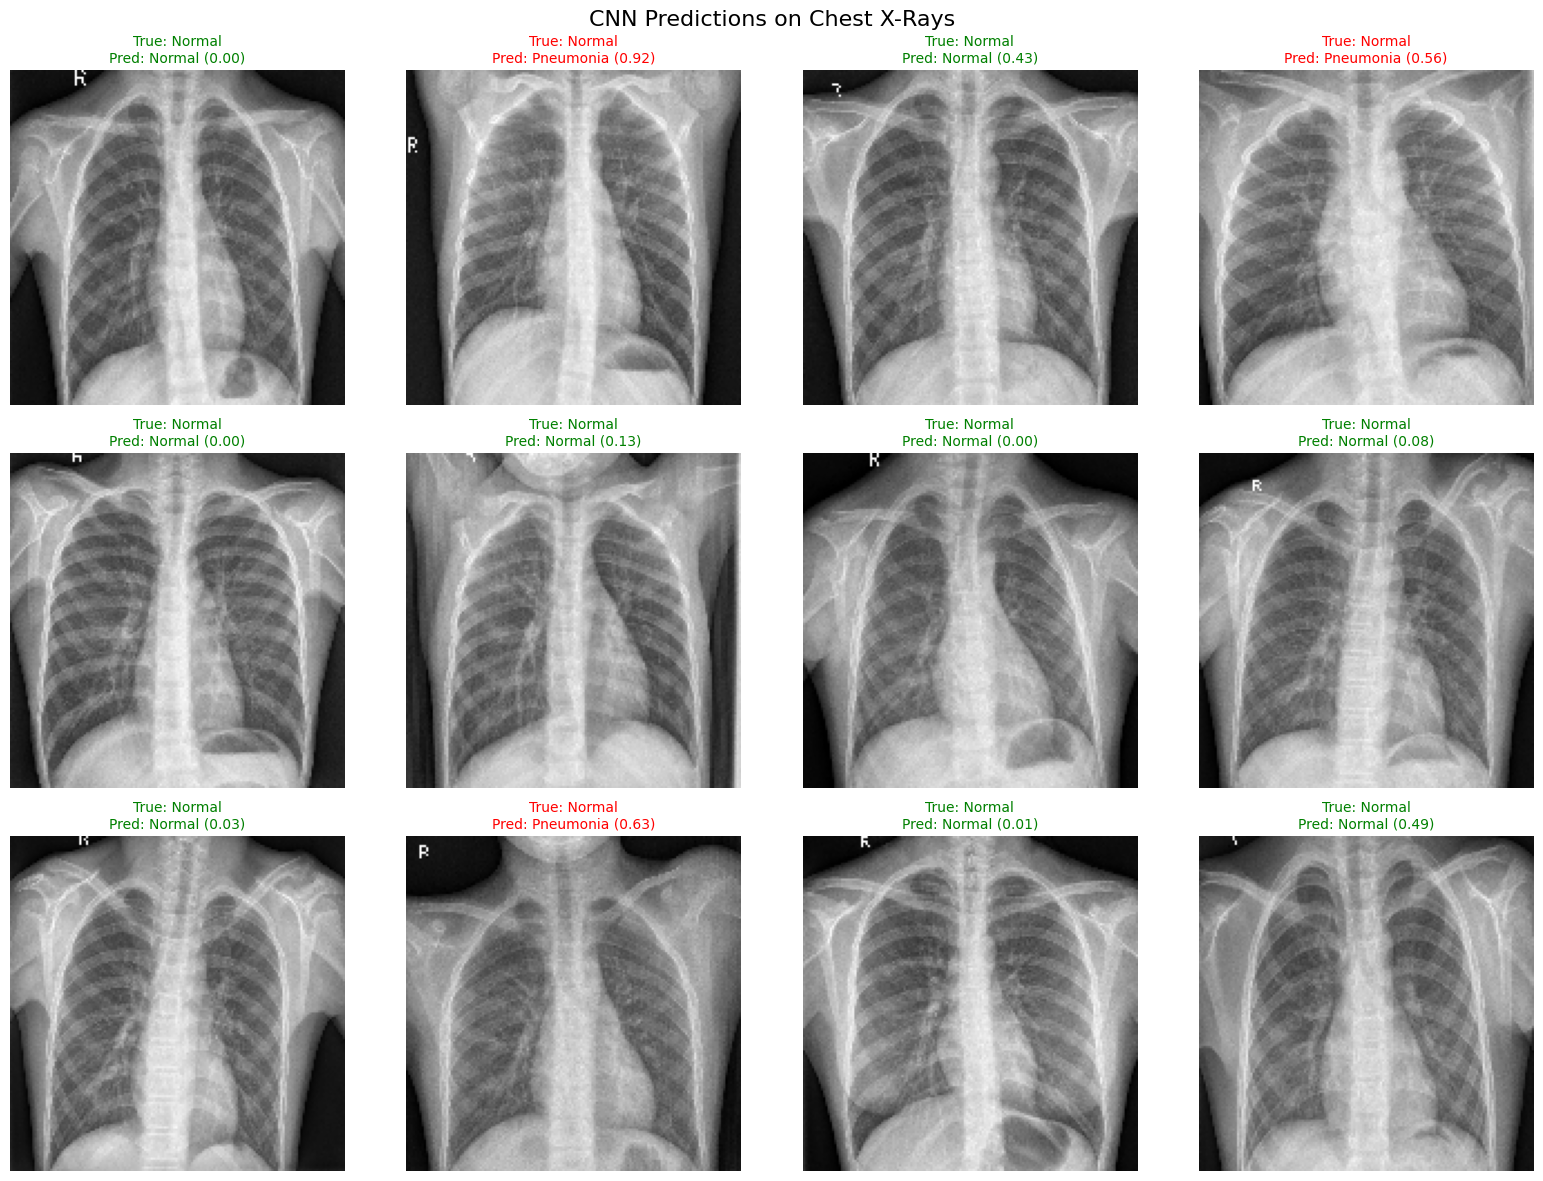

In [14]:
#lets show sample predictions
test_generator.reset()
images, labels = next(test_generator)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(12):
    img = images[i].reshape(150, 150)
    true_label = 'Pneumonia' if labels[i] == 1 else 'Normal'
    pred_prob = model.predict(images[i:i+1], verbose=0)[0][0]
    pred_label = 'Pneumonia' if pred_prob > 0.5 else 'Normal'
    correct = true_label == pred_label

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({pred_prob:.2f})",
        color='green' if correct else 'red',
        fontsize=10
    )
    axes[i].axis('off')

plt.suptitle('CNN Predictions on Chest X-Rays', fontsize=16)
plt.tight_layout()
plt.show()

## Key Findings

**Model:** 3-block CNN (32→64→128 filters) + Dense(128) + Sigmoid: **4,827,905 paramters** trained from scratch

**Dataset:** 5,216 chest X-rays across Normal and Pneumonia classes  2.9x class imbalance handled with class weights

**Result:** 96.92% Recall on test set the model correctly identified 378 out of 390 Pneumonia cases, Lets go!

**Tradeoff:** Normal Recall = 64% model raises false alarms on ambigous X-rays, but in a medical setting this is the right call, a false alarm means extra tests, a mised diagnosis means a patient goes home untreated

**Key techniques learned:**
- Conv2D filters learn edge/texture/pattern detection automatically through backpropagation
- MaxPooling compresses spatial size while preserving strongest signals
- ImageDataGenerator streams images in batches n no memory crash on large datasets
- Data augmentation (flip, rotate, zoom) artificialy expands training variety
- Recall > Accuracy when the cost of missing a positive case is life-threatening

**Next step:** Transfer Learning with ResNet50  plug in a model pretrained on millions of images and watch accuracy jump to 95%+

My first CNN project! We cooked!!